### US Monetary Policy
In this notebook I build a small macroeconomic modeling pipeline for the US economy.
The goal is to understand how the output gap, inflation and the Federal Funds Rate interact, and how simple macro models can be used for forecasting and scenario analysis.

The notebook has four main parts:

1. Data pipeline using FRED data.
2. Exploratory macro analysis and output gap construction.
3. A small VAR model with impulse responses and out-of-sample forecast.
4. A simplified QPM-style model for a +100 bp monetary policy shock scenario.

This is not a full central-bank model. It is a compact educational project that helps me understand the basic tools used in macroeconomic analysis.

### 1. Imports 

In [149]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pandas_datareader import data as web

import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error

import os
from dotenv import load_dotenv

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)

FIG_DIR = "../output/figures"
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(name):
    """Сохраняет текущий график в папку figures/"""
    plt.savefig(
        os.path.join(FIG_DIR, f"{name}.png"),
        dpi=200,
        bbox_inches="tight"
    )

### 2. FRED configuration

Public FRED series:

| Series | FRED ID | Frequency used |
|---|---|---|
| Real GDP | `GDPC1` | Quarterly |
| Potential GDP | `GDPPOT` | Quarterly |
| PCE Price Index | `PCEPI` | Quarterly |
| Federal Funds Rate | `FEDFUNDS` | Monthly → quarterly average |
| Unemployment Rate | `UNRATE` | Monthly → quarterly average |
| WTI Oil Price | `DCOILWTICO` | Daily → quarterly average |
| Broad Dollar Index | `DTWEXBGS` | Daily → quarterly average |

In [150]:
load_dotenv()
FRED_API_KEY = os.getenv("API_KEY")

RAW_DIR = "../data/raw"
os.makedirs(RAW_DIR, exist_ok=True)

START_DATE = "1990-01-01"
END_DATE = "2026-06-30"
fred_series = {
    "real_gdp": "GDPC1",
    "potential_gdp": "GDPPOT",
    "pce": "PCEPI",
    "fedfunds": "FEDFUNDS",
    "unemployment": "UNRATE",
    "oil": "DCOILWTICO",
    "dollar": "DTWEXBGS" 
}

In [151]:
raw = {}

for name, code in fred_series.items():
    raw[name] = web.DataReader(code, "fred", START_DATE, END_DATE)
    raw[name].columns = [name]

for name, df in raw.items():
    print(name, df.index.min().date(), df.index.max().date(), df.shape)

real_gdp 1990-01-01 2026-04-01 (146, 1)
potential_gdp 1990-01-01 2026-04-01 (146, 1)
pce 1990-01-01 2026-06-01 (438, 1)
fedfunds 1990-01-01 2026-06-01 (438, 1)
unemployment 1990-01-01 2026-06-01 (438, 1)
oil 1990-01-01 2026-06-30 (9522, 1)
dollar 2006-01-02 2026-06-30 (5347, 1)


### 3. Frequencies
Quarterly variables are kept quarterly.
Monthly and daily variables are converted to quarterly averages.

For GDP-type variables, I use the last quarterly observation.
For rates and prices, quarterly averages are more natural.

In [152]:
real_gdp_q = raw["real_gdp"].resample("QE").last()
potential_gdp_q = raw["potential_gdp"].resample("QE").last()

pce_q = raw["pce"].resample("QE").mean()
fedfunds_q = raw["fedfunds"].resample("QE").mean()
unemployment_q = raw["unemployment"].resample("QE").mean()

oil_q = raw["oil"].resample("QE").mean()
dollar_q = raw["dollar"].resample("QE").mean()

macro = pd.concat(
    [
        real_gdp_q,
        potential_gdp_q,
        pce_q,
        fedfunds_q,
        unemployment_q,
        oil_q,
        dollar_q
    ],
    axis=1
)
macro = macro.loc[:END_DATE].copy()
macro.tail()

,real_gdp,potential_gdp,pce,fedfunds,unemployment,oil,dollar
DATE,,,,,,,
2025-06-30,23884.563,23548.517662,126.433667,4.330000,4.200000,64.567258,122.415035
2025-09-30,24112.966,23680.152477,127.245333,4.293333,4.333333,65.779531,120.237222
2025-12-31,24125.479,23811.223897,128.096667,3.896667,4.450000,59.615968,120.748735
2026-03-31,24274.383,23945.137839,129.414333,3.640000,4.333333,72.735082,119.066351
2026-06-30,24408.011,24070.938648,131.006333,3.633333,4.266667,95.649677,119.303732


### 4. Construct macro variables

- output gap
- PCE inflation
- real GDP growth
- oil price inflation
- dollar appreciation


#### Estimate output gap as: x_t = 100*((log Y_t - log Y_t^)\log Y_t^), where (Y_t\) — in fact real GDP;(Y_t^) — potential GDP. If output gap is positive, the economy works more effectively than estimated.  If it is negative, it is below the potential level. 

In [153]:
macro["output_gap"] = 100 * (
    np.log(macro["real_gdp"]) - np.log(macro["potential_gdp"])
)
macro["inflation_yoy"] = 100 * (
    np.log(macro["pce"]) - np.log(macro["pce"].shift(4))
)
macro["inflation_qoq_ann"] = 400 * np.log(macro["pce"]).diff()
macro["real_gdp_growth"] = 400 * np.log(macro["real_gdp"]).diff()
macro["oil_inflation_yoy"] = 100 * (
    np.log(macro["oil"]) - np.log(macro["oil"].shift(4))
)
macro["dollar_appreciation_yoy"] = 100 * (
    np.log(macro["dollar"]) - np.log(macro["dollar"].shift(4))
)

# Baseline inflation variable
macro["inflation"] = macro["inflation_yoy"]
macro[[
    "output_gap",
    "inflation",
    "inflation_qoq_ann",
    "fedfunds",
    "unemployment",
    "real_gdp_growth"
]].dropna().tail()

,output_gap,inflation,inflation_qoq_ann,fedfunds,unemployment,real_gdp_growth
DATE,,,,,,
2025-06-30,1.416948,2.438934,2.368182,4.330000,4.200000,3.944092
2025-09-30,1.811246,2.653997,2.559674,4.293333,4.333333,3.806941
2025-12-31,1.311144,2.678880,2.667282,3.896667,4.450000,0.207519
2026-03-31,1.365631,2.922180,4.093583,3.640000,4.333333,2.461238
2026-06-30,1.390615,3.552787,4.890610,3.633333,4.266667,2.195921


### 5. Exploratory macro analysis


First I plot the main variables.

The most important recent macro episodes are:

- the Global Financial Crisis;
- the zero lower bound period;
- the COVID shock;
- the inflation surge after 2021;
- the Fed tightening cycle.

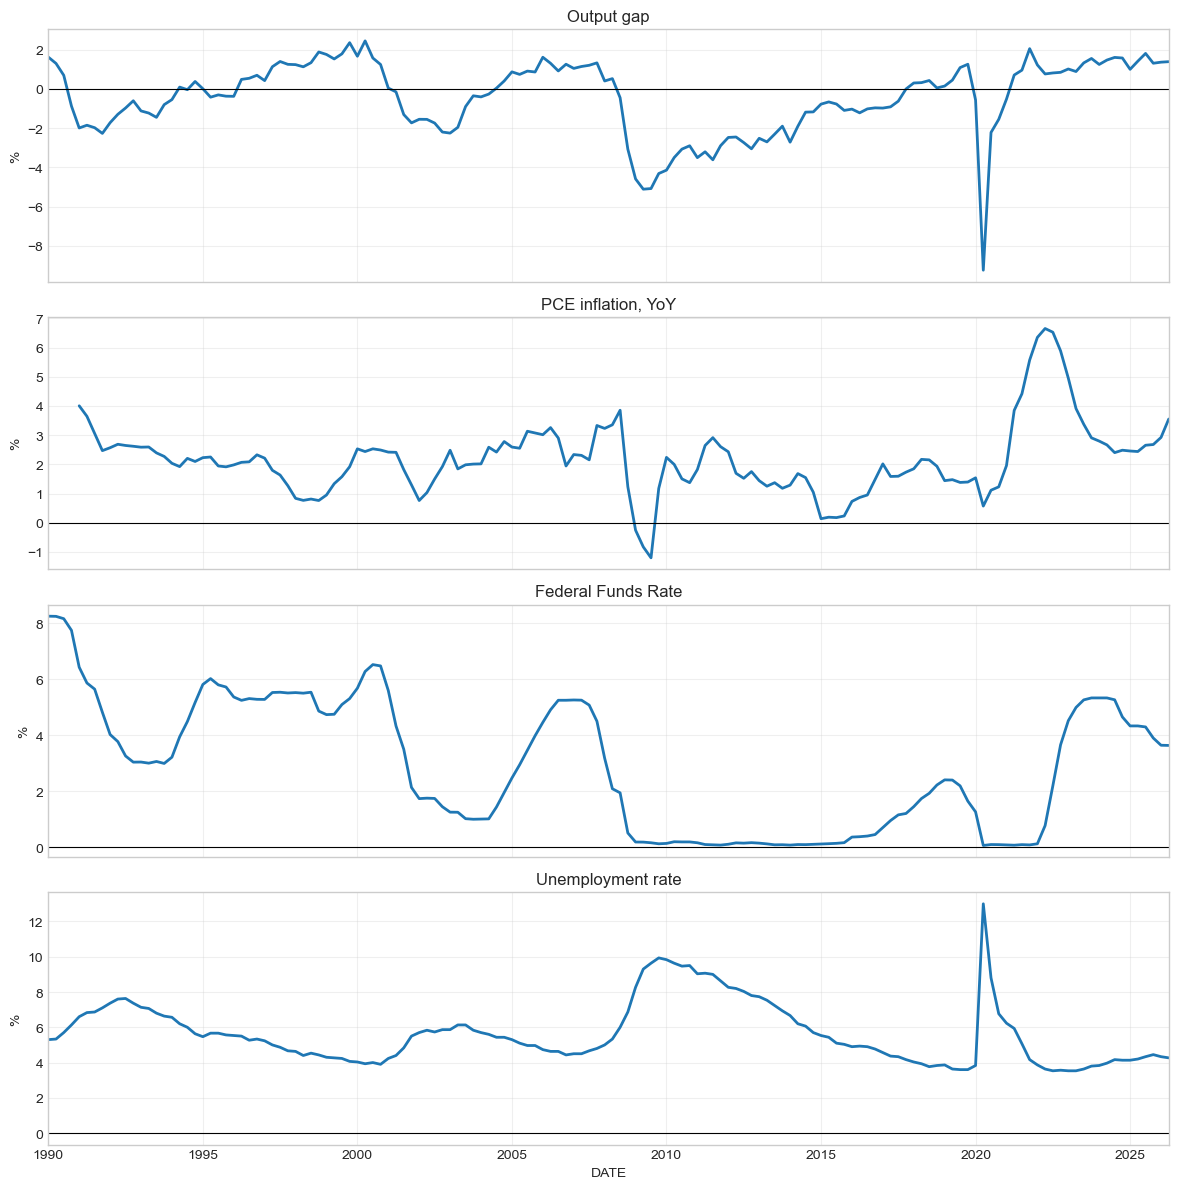

In [154]:
plot_cols = [
    "output_gap",
    "inflation",
    "fedfunds",
    "unemployment"
]

titles = [
    "Output gap",
    "PCE inflation, YoY",
    "Federal Funds Rate",
    "Unemployment rate"
]

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

for ax, col, title in zip(axes, plot_cols, titles):
    macro[col].plot(ax=ax, linewidth=2)
    ax.set_title(title)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel("%")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_fig("01_macro_overview")
plt.show()

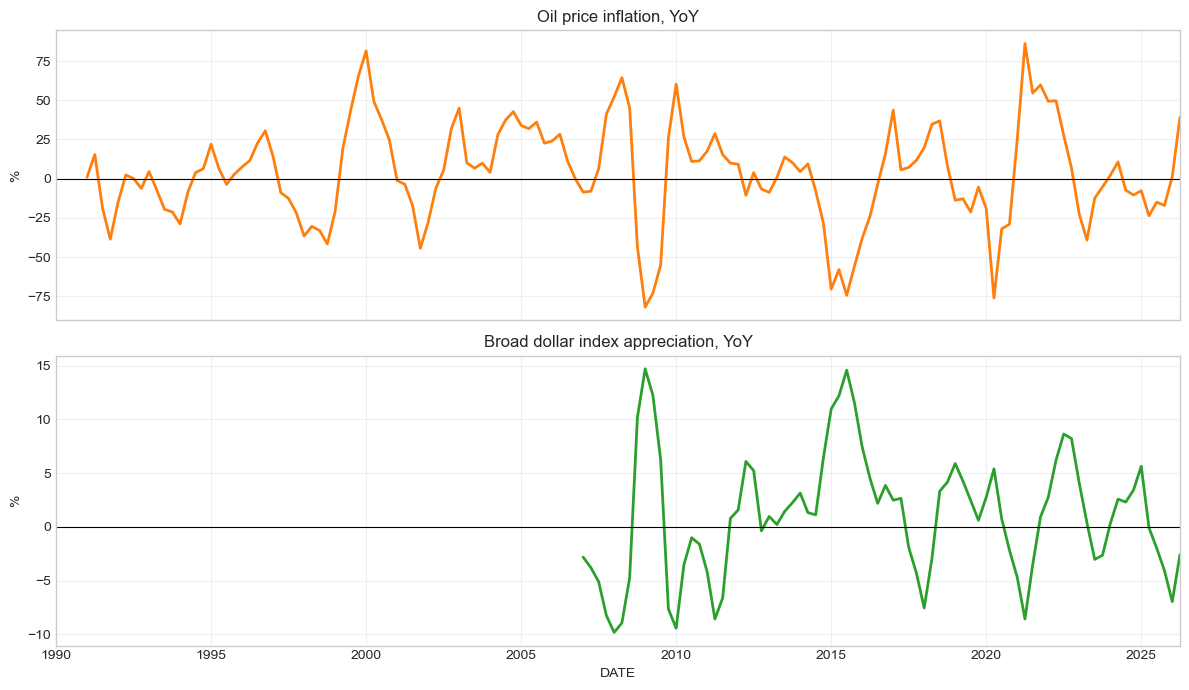

In [155]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

macro["oil_inflation_yoy"].plot(ax=axes[0], linewidth=2, color="tab:orange")
axes[0].set_title("Oil price inflation, YoY")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("%")

macro["dollar_appreciation_yoy"].plot(ax=axes[1], linewidth=2, color="tab:green")
axes[1].set_title("Broad dollar index appreciation, YoY")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("%")

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_fig("02_oil_dollar")
plt.show()

### 6. Stationarity check

Before estimating a VAR, I check stationarity using the Augmented Dickey-Fuller test.

In macroeconomics, the test should not be used mechanically. Some variables may look persistent but are still used in levels because their level has economic meaning.

For this small VAR, I use:

- output gap;
- inflation;
- Federal Funds Rate.

In [156]:
def adf_test(series, name):
    series = series.dropna()
    result = adfuller(series, autolag="AIC")
    
    return {
        "variable": name,
        "ADF statistic": result[0],
        "p-value": result[1],
        "nobs": result[3]
    }

adf_results = []

for col in ["output_gap", "inflation", "fedfunds"]:
    adf_results.append(adf_test(macro[col], col))

adf_table = pd.DataFrame(adf_results)
adf_table

,variable,ADF statistic,p-value,nobs
0,output_gap,-3.711665,0.003952,145
1,inflation,-1.642419,0.460997,129
2,fedfunds,-3.353827,0.012637,144


#### The Augmented Dickey-Fuller test evaluates:
At the 5% significance level: 
output gap: the unit-root null is rejected; 
inflation: the unit-root null is not rejected; 
Federal Funds Rate: the result is borderline and the unit-root null is not rejected at 5%. ADF tests can have low power in relatively small macroeconomic samples. For the baseline monetary VAR, the variables are kept in levels because the goal is to study monetary-policy dynamics in interpretable macro variables, not only to optimize statistical stationarity.

### 6. VAR model

A VAR is a reduced-form model. It does not impose deep economic structure.
It answers the question: How do these variables move together over time?

I estimate a small quarterly VAR with:[(outputgap,inflation,fedfunds)]

The ordering for impulse responses is:

1. output gap
2. inflation
3. Federal Funds Rate

This means that within a quarter the Fed Funds Rate can react to output and inflation, while output and inflation react to a policy shock with a lag. This is a simplifying identification assumption.

In [157]:
VAR_COLUMNS_EXT = ["oil_inflation_yoy", "output_gap", "inflation", "fedfunds"]
var_data_ext = macro[VAR_COLUMNS_EXT].dropna().copy()

print("Расширенный VAR sample:")
print(var_data_ext.index.min(), "to", var_data_ext.index.max())
print(var_data_ext.shape)

Расширенный VAR sample:
1991-03-31 00:00:00 to 2026-06-30 00:00:00
(142, 4)


In [158]:
model_ext = VAR(var_data_ext)

lag_order_results_ext = model_ext.select_order(maxlags=8)
print(lag_order_results_ext.summary())

selected_lag_ext = lag_order_results_ext.aic
if selected_lag_ext is None or selected_lag_ext == 0:
    selected_lag_ext = 2
selected_lag_ext = int(selected_lag_ext)

print(f"Chosen lag for model_ext {selected_lag_ext}")

var_results_ext = model_ext.fit(selected_lag_ext)
print(var_results_ext.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       8.848       8.935       6963.       8.883
1       1.764       2.196       5.836       1.940
2     0.9938*      1.772*      2.704*      1.310*
3       1.052       2.176       2.870       1.509
4       1.199       2.669       3.334       1.796
5       1.012       2.828       2.779       1.750
6       1.036       3.198       2.867       1.914
7       1.148       3.656       3.241       2.167
8       1.214       4.069       3.509       2.374
-------------------------------------------------
Chosen lag for model_ext 2
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 03, Oct, 2026
Time:                     18:35:13
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    1.67297
Nobs:     

In [159]:
print("VAR stable:", var_results_ext.is_stable())

roots = var_results_ext.roots
print("Max root modulus:", np.max(np.abs(roots)))

VAR stable: True
Max root modulus: 7.6952110086264165


### VAR estimation results

All 4 information criteria (AIC, BIC, FPE, HQIC) select 2 lags, which gives confidence that the lag specification is not arbitrary.

### Oil
Oil prices are explained almost entirely by their own history (coefficient of 1.18 at the first lag, -0.46 at the second). Neither the output gap, inflation, nor the Fed rate has a statistically significant effect on oil prices (p-values are above 0.4 in all cases).
Conclusion: Oil behaves like an external shock—it does not depend on the rest of the US economy, yet it can influence it. Therefore, it makes sense to place it first in the Cholesky ordering.

### Output Gap
The output gap is quite persistent (0.61 at the first lag)—the economy changes gradually rather than in sudden jumps.
The coefficients for the Fed rate (+0.53 at lag 1, -0.43 at lag 2) contradict each other and almost cancel out when summed. This is a classic case of multicollinearity between adjacent lags of the same persistent variable. Consequently, I do not interpret these coefficients individually; it is better to look at the impulse response functions (IRFs).

### Inflation
Inflation is highly persistent (coefficient of nearly 1.0 at the first lag). This is expected, as year-over-year inflation is calculated using overlapping 12-month windows, making it "smoothed" by construction.
Oil significantly predicts inflation (p=0.008 and p=0.003 at the two lags). The Fed rate does not significantly affect inflation over a 1–2 quarter horizon (p=0.68, p=0.97). This is consistent with standard theory (Friedman), which holds that monetary policy impacts inflation with a lag of 12–24 months, rather than 1–2 quarters. 

### Residual Correlation
The correlation between oil and inflation is 0.78—a very high figure. This indicates that they frequently move in tandem within the same quarter.

### Conclusion
The results confirm that incorporating oil into the model—replacing the initial three-variable VAR (output gap, inflation, Fed rate) and using the correct variable ordering (oil → output gap → inflation → rate)—should yield more realistic impulse response functions (IRFs).
The next step is therefore to a examine a monetary-policy dynamic effects using impulse response functions(IRF).

### 7. Residual autocorrelation

In [160]:
# Test whether residual serial correlation remains in the VAR.
whiteness_test = var_results.test_whiteness(
    nlags=max(8, selected_lag + 1),
)

print(whiteness_test.summary())

Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 8 is zero. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         134.2          119.9   0.006 96
----------------------------------------


The Portmanteau test rejects the null hypothesis of no residual autocorrelation at the 5% significance level.

This means that there is some evidence of remaining serial correlation in the VAR residuals up to lag 8. Therefore, the VAR(2) may not fully capture all temporal dynamics in the data.

### 8. Impulse Response Functions
#### We now examine the economy's response to a monetary policy shock using impulse response functions. This is a Cholesky shock, so it should not be interpreted as a perfect causal monetary policy shock. 

In [161]:
horizon = 16
irf_ext_v2 = var_results_ext.irf(horizon)

var_names_ext = var_results_ext.names
impulse_idx = var_names_ext.index("fedfunds")
response_vars = ["fedfunds", "output_gap", "inflation"]

irf_values_v2 = irf_ext_v2.orth_irfs

irf_df_v2 = pd.DataFrame(
    {
        r: irf_values_v2[:, var_names_ext.index(r), impulse_idx]
        for r in response_vars
    },
    index=range(horizon + 1)
)

irf_df_v2

,fedfunds,output_gap,inflation
0,0.266254,0.000000,0.000000
1,0.439252,0.140389,-0.011787
2,0.535413,0.200946,-0.028008
3,0.576101,0.230825,-0.043038
4,0.576428,0.236589,-0.055277
5,0.548571,0.226599,-0.064105
6,0.502096,0.206502,-0.069593
7,0.444444,0.180515,-0.072167
8,0.381308,0.151723,-0.072377
9,0.316946,0.122366,-0.070760


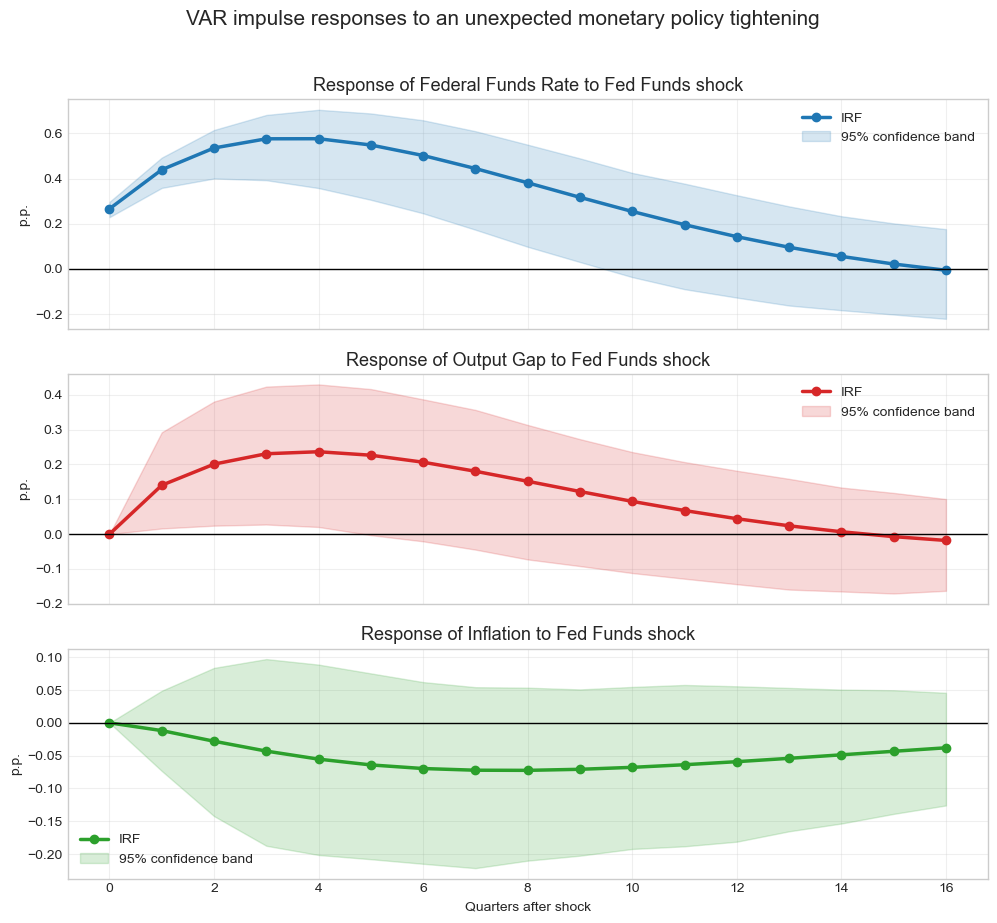

In [162]:
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

titles = {
    "fedfunds": "Federal Funds Rate",
    "output_gap": "Output Gap",
    "inflation": "Inflation"
}

colors = {
    "fedfunds": "tab:blue",
    "output_gap": "tab:red",
    "inflation": "tab:green"
}

for ax, response in zip(axes, response_vars):
    response_idx = var_names.index(response)
    
    point = irf_values[:, response_idx, impulse_idx]
    low = lower[:, response_idx, impulse_idx]
    high = upper[:, response_idx, impulse_idx]
    
    ax.plot(
        quarters,
        point,
        color=colors[response],
        linewidth=2.5,
        marker="o",
        label="IRF"
    )
    
    ax.fill_between(
        quarters,
        low,
        high,
        color=colors[response],
        alpha=0.18,
        label="95% confidence band"
    )
    
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"Response of {titles[response]} to Fed Funds shock", fontsize=13)
    ax.set_ylabel("p.p.")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")

axes[-1].set_xlabel("Quarters after shock")

fig.suptitle(
    "VAR impulse responses to an unexpected monetary policy tightening",
    fontsize=15,
    y=1.02
)

plt.tight_layout()
save_fig("03_var_irf")
plt.show()

The IRF — Impulse Response Function— provides a rough estimate. It asks: Show how the system will react over the next 16 quarters if an unexpected shock occurs right now. For example, suppose the Fed unexpectedly tightens monetary policy: what happens next to the interest rate, the output gap, and inflation? 

After incorporating oil price inflation and adjusting the Cholesky ordering (oil → output gap → inflation → interest rate), the impulse responses became economically consistent:

- Inflation now falls following an interest rate shock across the entire horizon (ranging from 0 to -0.07 percentage points, with the trough at quarters 8–9).
- The output gap initially rises slightly (due to transmission lag effects) but then reverses course, moving into negative territory (-0.018) by the end of the horizon (quarter 16); this aligns with theory, as policy tightening gradually cools the economy.
- The response of the interest rate itself shows a persistent rise, peaking at quarters 3–4 (~0.58 percentage points) followed by a gradual decline.

Conclusion: Including oil in the model and correctly positioning it within the Cholesky ordering yields results consistent with standard monetary transmission theory: a rate hike leads to a narrowing output gap and lower inflation, with a characteristic lag of several quarters.

### 9. VAR forecast and benchmark

Now I make a simple out-of-sample forecast.
A macro model should be compared with a simple benchmark. Here I compare the VAR forecast with a random-walk / last-observation forecast.

In [163]:
test_size = 12

train_ext = var_data_ext.iloc[:-test_size].copy()
test_ext = var_data_ext.iloc[-test_size:].copy()

var_train_model_ext = VAR(train_ext)
var_train_results_ext = var_train_model_ext.fit(selected_lag_ext)

lagged_values_ext = train_ext.values[-selected_lag_ext:]
forecast_values_ext = var_train_results_ext.forecast(
    y=lagged_values_ext,
    steps=test_size
)

var_forecast_ext = pd.DataFrame(
    forecast_values_ext,
    index=test_ext.index,
    columns=VAR_COLUMNS_EXT
)

var_forecast_ext.head()

,oil_inflation_yoy,output_gap,inflation,fedfunds
DATE,,,,
2023-09-30,-39.124172,0.929668,3.421178,5.523605
2023-12-31,-31.847321,1.087583,3.164259,5.987962
2024-03-31,-23.317256,1.222303,3.010071,6.341067
2024-06-30,-16.243132,1.304288,2.888302,6.570733
2024-09-30,-11.352774,1.324630,2.766361,6.679690


In [164]:
rw_forecast_ext = pd.DataFrame(index=test_ext.index, columns=VAR_COLUMNS_EXT)

for col in VAR_COLUMNS_EXT:
    rw_forecast_ext[col] = train_ext[col].iloc[-1]

rmse_results_ext = []

for col in VAR_COLUMNS_EXT:
    var_rmse = np.sqrt(mean_squared_error(test_ext[col], var_forecast_ext[col]))
    rw_rmse = np.sqrt(mean_squared_error(test_ext[col], rw_forecast_ext[col]))
    
    rmse_results_ext.append({
        "variable": col,
        "VAR_RMSE": var_rmse,
        "RandomWalk_RMSE": rw_rmse,
        "VAR/RW": var_rmse / rw_rmse
    })

forecast_comparison_ext = pd.DataFrame(rmse_results_ext)
forecast_comparison_ext

,variable,VAR_RMSE,RandomWalk_RMSE,VAR/RW
0,oil_inflation_yoy,20.657142,38.744610,0.533162
1,output_gap,0.488407,0.570430,0.856208
2,inflation,0.566955,1.186432,0.477865
3,fedfunds,1.666082,0.754154,2.209207


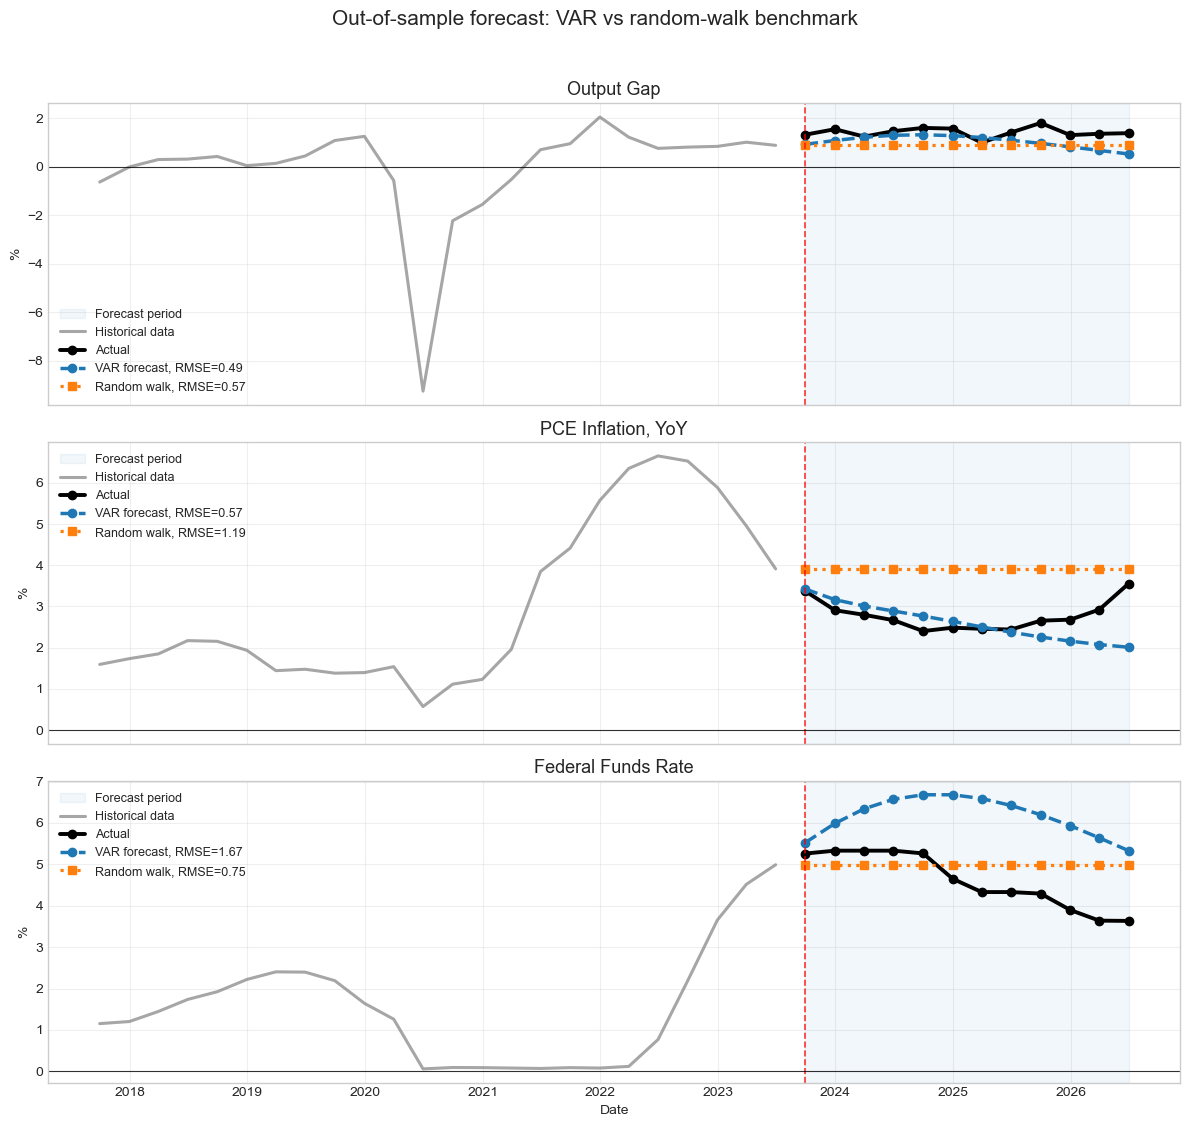

In [165]:
history_window = 24

pretty_names = {
    "output_gap": "Output Gap",
    "inflation": "PCE Inflation, YoY",
    "fedfunds": "Federal Funds Rate",
    "oil_inflation_yoy": "Oil Price Inflation, YoY"
}

plot_cols = ["output_gap", "inflation", "fedfunds"]

test_start = test_ext.index[0]

fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)

for ax, col in zip(axes, plot_cols):
    
    var_rmse = np.sqrt(mean_squared_error(test_ext[col], var_forecast_ext[col]))
    rw_rmse = np.sqrt(mean_squared_error(test_ext[col], rw_forecast_ext[col]))
    
    ax.axvspan(
        test_ext.index[0],
        test_ext.index[-1],
        color="tab:blue",
        alpha=0.06,
        label="Forecast period"
    )
    
    ax.plot(
        train_ext[col].iloc[-history_window:].index,
        train_ext[col].iloc[-history_window:].values,
        label="Historical data",
        color="gray",
        linewidth=2.2,
        alpha=0.7
    )
    
    ax.plot(
        test_ext.index,
        test_ext[col].values,
        label="Actual",
        color="black",
        linewidth=2.8,
        marker="o"
    )
    
    ax.plot(
        var_forecast_ext.index,
        var_forecast_ext[col].values,
        label=f"VAR forecast, RMSE={var_rmse:.2f}",
        color="tab:blue",
        linewidth=2.5,
        linestyle="--",
        marker="o"
    )
    
    ax.plot(
        rw_forecast_ext.index,
        rw_forecast_ext[col].values,
        label=f"Random walk, RMSE={rw_rmse:.2f}",
        color="tab:orange",
        linewidth=2.3,
        linestyle=":",
        marker="s"
    )
    
    ax.axvline(test_start, color="red", linestyle="--", linewidth=1.2, alpha=0.8)
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.8)
    
    ax.set_title(pretty_names.get(col, col), fontsize=13)
    ax.set_ylabel("%")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=9)

axes[-1].set_xlabel("Date")

fig.suptitle(
    "Out-of-sample forecast: VAR vs random-walk benchmark",
    fontsize=15,
    y=1.02
)

plt.tight_layout()
save_fig("04_var_forecast")
plt.show()

## Forecast evaluation
Comparing VAR forecasts to a random-walk benchmark gives mixed results:

- For oil inflation, the output gap, and PCE inflation, the VAR outperforms the random walk (VAR/RW ratios of 0.53, 0.86, and 0.48 respectively) — the VAR RMSE is up to twice as small.
- For the Federal Funds Rate, the VAR performs significantly worse than the random walk (VAR/RW = 2.21). The VAR, estimated on a sample ending during an aggressive tightening cycle, extrapolates the recent upward trend in rates and predicts a further increase to around 6.7% by late 2024. In reality, the Fed held rates steady and then began cutting, bringing the rate down to about 3.6% by 2026.

This illustrates a common limitation of VAR models: they extrapolate historical momentum and cannot anticipate forward-looking policy decisions that depend on information outside the model (e.g., FOMC communication about future rate cuts). In this case, a naive "no change" forecast turned out to be a better guide to the policy rate than a statistical model trained on the recent tightening cycle.

In [166]:
# forecast of the future # optional
var_full = VAR(var_data_ext).fit(selected_lag_ext)

future_steps = 8
future_index = pd.date_range(
    start=var_data_ext.index[-1] + pd.offsets.QuarterEnd(1),
    periods=future_steps,
    freq="QE"
)

future_forecast = pd.DataFrame(
    var_full.forecast(var_data_ext.values[-selected_lag_ext:], steps=future_steps),
    index=future_index,
    columns=VAR_COLUMNS_EXT
)

future_forecast.round(2)

,oil_inflation_yoy,output_gap,inflation,fedfunds
2026-09-30,43.09,1.19,3.86,3.73
2026-12-31,30.78,0.99,3.78,3.83
2027-03-31,15.37,0.78,3.51,3.90
2027-06-30,3.59,0.64,3.19,3.98
2027-09-30,-2.81,0.55,2.93,4.04
2027-12-31,-4.79,0.50,2.75,4.09
2028-03-31,-4.15,0.48,2.62,4.13
2028-06-30,-2.47,0.46,2.54,4.14


The out-of-sample test simulates a real forecasting situation: the model is estimated only on data up to 2023Q2 and then predicts the next 12 quarters without seeing them. 
In-sample fit is not a good measure of forecasting ability, because the model is fitted to exactly those data. 
The random walk serves as a simple benchmark: a useful model should beat a "no change" forecast.

### 10. QPM — Simplified Quarterly Projection Model

The QPM (Quarterly Projection Model) is a semi-structural model used by central banks for scenario analysis. Unlike a VAR model, it does not merely describe the data but establishes the economic logic behind the transmission of monetary policy.

My model consists of three equations:

**1. IS curve (demand):**

$$x_t = \alpha_x x_{t-1} - \alpha_r (i_{t-1} - \pi_{t-1} - r^*)$$

The output gap depends on its own lagged value and the extent to which the real interest rate exceeds the neutral rate. If the rate is above neutral, borrowing costs are high, and demand falls.

**2. Phillips curve (inflation):**

$$\pi_t = \beta_\pi \pi_{t-1} + (1-\beta_\pi)\pi^* + \beta_x x_{t-1}$$

Inflation exhibits inertia and gradually returns to the 2% target. If the economy is "overheated" (output gap > 0), inflation rises.

**3. Fed rule (interest rate):**

$$i_t = \rho i_{t-1} + (1-\rho)\left[r^* + \pi^* + \phi_\pi(\pi_t-\pi^*) + \phi_x x_t\right]$$

The Fed raises the interest rate if inflation exceeds the target or the economy is overheated, but it does so gradually.

Notation: $x_t$ — output gap, $\pi_t$ — inflation, $i_t$ — Fed interest rate, $\pi^* = 2\%$ — inflation target, $r^*$ — neutral real interest rate.

STEP 1. Here’s what’s happening: we are calculating the real interest rate (the rate minus inflation) and the neutral rate, r*. The neutral rate is the rate at which the economy neither accelerates nor slows down. Since it cannot be observed directly, we use a simple approximation: the average real rate since 2010.

In [167]:
INFLATION_TARGET = 2.0

qpm_data = macro[["output_gap", "inflation", "fedfunds"]].dropna().copy()

# Lags
qpm_data["output_gap_lag"] = qpm_data["output_gap"].shift(1)
qpm_data["inflation_lag"] = qpm_data["inflation"].shift(1)
qpm_data["fedfunds_lag"] = qpm_data["fedfunds"].shift(1)


qpm_data["real_rate"] = qpm_data["fedfunds"] - qpm_data["inflation"]

# Neutral real rate: a simple approximation using the average since 2010
r_star = qpm_data["real_rate"].loc["2010":].mean()

# Real rate gap: how much tougher/softer is the policy than neutral?
qpm_data["real_rate_gap_lag"] = qpm_data["real_rate"].shift(1) - r_star
qpm_data["inflation_gap_lag"] = qpm_data["inflation_lag"] - INFLATION_TARGET

qpm_reg = qpm_data.dropna().copy()

print(f"Neutral real rate (r*): {r_star:.2f}%")
print(f"Sample: {qpm_reg.index.min().date()} – {qpm_reg.index.max().date()}")

Neutral real rate (r*): -0.77%
Sample: 1991-06-30 – 2026-06-30


STEP 2. OLS estimates. Purpose: Before setting parameters manually, we see what the data says. This is a check, not the final model.

While OLS performs well in estimating variable persistence, it is poor at capturing the impact of the interest rate on the economy. The reason is that the Federal Reserve raises rates precisely when the economy is strong and inflation is high. Consequently, the data often show high interest rates coinciding with a large positive output gap; this can lead OLS to suggest a relationship where "high rates → economic growth." This reflects the Fed's reaction to economic conditions rather than a causal link (the endogeneity problem).

Therefore, just as with the actual Quarterly Projection Models (QPMs) used by central banks, I **calibrate** the parameters: I set their values to align with economic theory and ensure they are consistent with typical values ​​found in the literature. OLS estimates serve merely as a reference point for persistence.

In [168]:
# 1. IS-сurve 
is_model = sm.OLS(
    qpm_reg["output_gap"],
    sm.add_constant(qpm_reg[["output_gap_lag", "real_rate_gap_lag"]])
).fit()

# 2. Phillips curve
pc_model = sm.OLS(
    qpm_reg["inflation"],
    sm.add_constant(qpm_reg[["inflation_lag", "output_gap_lag"]])
).fit()

# 3. FRS Taylor rule
rule_model = sm.OLS(
    qpm_reg["fedfunds"],
    sm.add_constant(qpm_reg[["fedfunds_lag", "inflation_gap_lag", "output_gap_lag"]])
).fit()

ols_table = pd.DataFrame({
    "Equation": ["IS curve", "IS curve", "Phillips curve", "Phillips curve",
                 "Policy rule", "Policy rule", "Policy rule"],
    "Variable": ["output_gap_lag", "real_rate_gap_lag",
                 "inflation_lag", "output_gap_lag",
                 "fedfunds_lag", "inflation_gap_lag", "output_gap_lag"],
    "Expected sign": ["+", "−", "+", "+", "+", "+", "+"],
    "Coefficient": [
        is_model.params["output_gap_lag"], is_model.params["real_rate_gap_lag"],
        pc_model.params["inflation_lag"], pc_model.params["output_gap_lag"],
        rule_model.params["fedfunds_lag"], rule_model.params["inflation_gap_lag"],
        rule_model.params["output_gap_lag"]
    ],
    "p-value": [
        is_model.pvalues["output_gap_lag"], is_model.pvalues["real_rate_gap_lag"],
        pc_model.pvalues["inflation_lag"], pc_model.pvalues["output_gap_lag"],
        rule_model.pvalues["fedfunds_lag"], rule_model.pvalues["inflation_gap_lag"],
        rule_model.pvalues["output_gap_lag"]
    ]
})

ols_table.round(3)

,Equation,Variable,Expected sign,Coefficient,p-value
0,IS curve,output_gap_lag,+,0.806,0.000
1,IS curve,real_rate_gap_lag,−,0.048,0.258
2,Phillips curve,inflation_lag,+,0.886,0.000
3,Phillips curve,output_gap_lag,+,0.020,0.438
4,Policy rule,fedfunds_lag,+,0.932,0.000
5,Policy rule,inflation_gap_lag,+,0.073,0.020
6,Policy rule,output_gap_lag,+,0.057,0.028


Step 4. Calibration

In [169]:
qpm_params = {
    # FROM OLS
    "alpha_x": 0.80,    
    "beta_pi": 0.85,   
    "rho": 0.90,      

    # Calibration (OLS is not enough)
    "alpha_r": 0.15,   # OLS give the wrong sign (endogenity)
    "beta_x": 0.08,    # OLS gives p-value > 0.05

    # Taylor rule standart values 
    "phi_pi": 1.50,
    "phi_x": 0.50
}

From OLS to ==>> calibration

The OLS regressions are used as a diagnostic step. Where the data give reliable estimates (persistence of the output gap, inflation and the policy rate), I set the QPM parameters close to the OLS values.

Where OLS is unreliable, I calibrate the parameters. The effect of the real rate on demand has the wrong sign in OLS because of endogeneity: the Fed raises rates when the economy is already strong. The Phillips curve slope is close to zero and insignificant. For these parameters I use small values with theoretically correct signs. The Taylor-rule coefficients follow standard values (φπ = 1.5, φx = 0.5).

This mix of estimation and calibration is standard practice in semi-structural QPMs used by central banks.

Step 5. Simulation

In [170]:
def simulate_qpm(initial_output_gap, initial_inflation, initial_rate,
                 r_star, params, periods=12, policy_shock=None):
    if policy_shock is None:
        policy_shock = {}

    p = params
    x_prev, pi_prev, i_prev = initial_output_gap, initial_inflation, initial_rate
    results = []

    for t in range(1, periods + 1):
       # 1. IS curve: demand responds to the real interest rate of the previous quarter.
        real_rate_gap_prev = i_prev - pi_prev - r_star
        x_t = p["alpha_x"] * x_prev - p["alpha_r"] * real_rate_gap_prev

       # 2. Phillips curve: inflation responds to the previous quarter's output gap
        pi_t = (p["beta_pi"] * pi_prev
                + (1 - p["beta_pi"]) * INFLATION_TARGET
                + p["beta_x"] * x_prev)

        # 3. The Fed’s rule: the “desired” Taylor rate + a gradual move toward it.
        taylor_rate = (r_star + INFLATION_TARGET
                       + p["phi_pi"] * (pi_t - INFLATION_TARGET)
                       + p["phi_x"] * x_t)
        i_t = p["rho"] * i_prev + (1 - p["rho"]) * taylor_rate

        # Unexpected rate shock
        i_t += policy_shock.get(t, 0.0)

        results.append({
            "quarter": t,
            "fedfunds": i_t,
            "output_gap": x_t,
            "inflation": pi_t,
            "real_rate_gap": i_t - pi_t - r_star
        })

        x_prev, pi_prev, i_prev = x_t, pi_t, i_t

    return pd.DataFrame(results).set_index("quarter")

Step 6. Baseline. The baseline is a forecast of "what would happen if the Fed did nothing unexpected." The model starts with the latest actual data (Q2 2026) and proceeds based on its own equations.

In [171]:
initial_output_gap = qpm_data["output_gap"].iloc[-1]
initial_inflation = qpm_data["inflation"].iloc[-1]
initial_rate = qpm_data["fedfunds"].iloc[-1]

start_point = pd.Series({
    "Output gap": initial_output_gap,
    "Inflation": initial_inflation,
    "Fed Funds Rate": initial_rate,
    "Neutral real rate (r*)": r_star,
    "Taylor-rule rate": r_star + INFLATION_TARGET
                        + qpm_params["phi_pi"] * (initial_inflation - INFLATION_TARGET)
                        + qpm_params["phi_x"] * initial_output_gap
}, name=f"Starting point ({qpm_data.index[-1].date()})").round(2)

start_point.to_frame()

,Starting point (2026-06-30)
Output gap,1.39
Inflation,3.55
Fed Funds Rate,3.63
Neutral real rate (r*),-0.77
Taylor-rule rate,4.26


In [172]:
baseline = simulate_qpm(initial_output_gap, initial_inflation, initial_rate,
                        r_star, qpm_params, periods=12)

baseline.round(2)

,fedfunds,output_gap,inflation,real_rate_gap
quarter,,,,
1,3.66,0.99,3.43,0.99
2,3.64,0.64,3.30,1.11
3,3.59,0.34,3.15,1.21
4,3.51,0.09,3.01,1.27
5,3.41,-0.12,2.86,1.31
6,3.28,-0.29,2.72,1.33
7,3.14,-0.43,2.59,1.32
8,3.00,-0.54,2.47,1.30
9,2.84,-0.63,2.36,1.26


Step 7. Shock effect +100 bp. 

In [173]:
shock = simulate_qpm(initial_output_gap, initial_inflation, initial_rate,
                     r_star, qpm_params, periods=12, policy_shock={1: 1.0})

# Shock effect = difference between the scenario and the baseline
shock_effect = shock - baseline

shock_effect.round(3)

,fedfunds,output_gap,inflation,real_rate_gap
quarter,,,,
1,1.000,0.000,0.000,1.000
2,0.893,-0.150,0.000,0.893
3,0.789,-0.254,-0.012,0.801
4,0.689,-0.323,-0.031,0.720
5,0.594,-0.367,-0.052,0.646
6,0.504,-0.390,-0.073,0.578
7,0.420,-0.399,-0.094,0.513
8,0.341,-0.396,-0.111,0.453
9,0.269,-0.385,-0.126,0.395


Step 8. Graphs

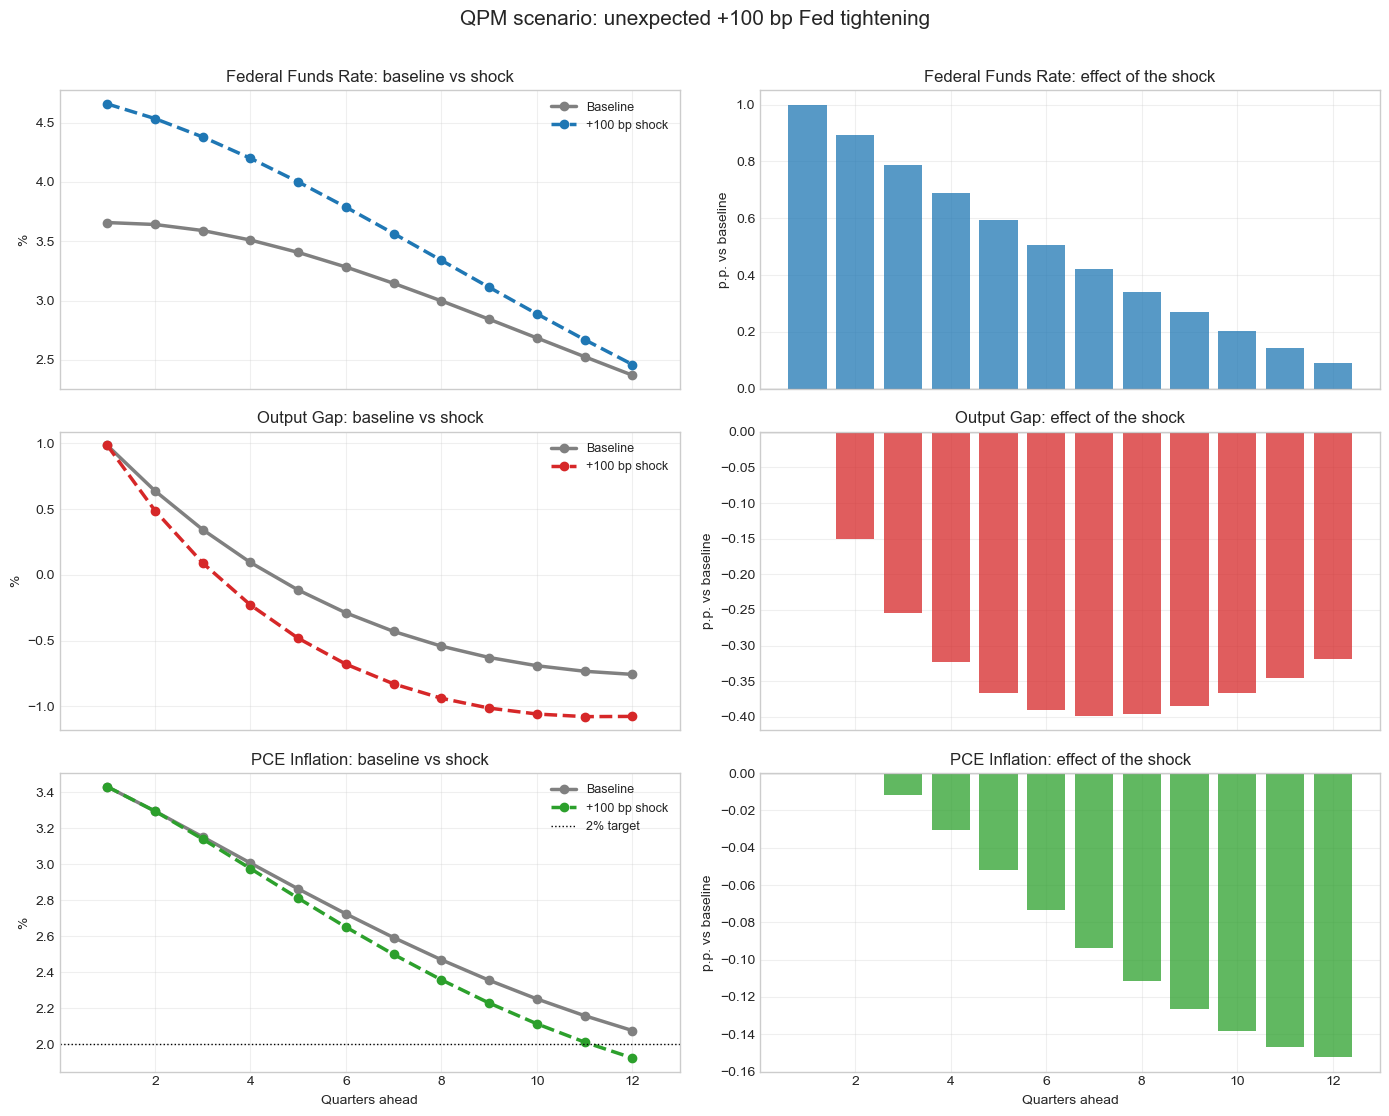

<Figure size 640x480 with 0 Axes>

In [174]:
variables = {
    "fedfunds": "Federal Funds Rate",
    "output_gap": "Output Gap",
    "inflation": "PCE Inflation"
}
colors = {"fedfunds": "tab:blue", "output_gap": "tab:red", "inflation": "tab:green"}

fig, axes = plt.subplots(3, 2, figsize=(14, 11), sharex=True)

for row, (col, title) in enumerate(variables.items()):
    # Левая колонка: уровни (baseline vs shock)
    ax = axes[row, 0]
    ax.plot(baseline.index, baseline[col], color="gray", linewidth=2.5,
            marker="o", label="Baseline")
    ax.plot(shock.index, shock[col], color=colors[col], linewidth=2.5,
            linestyle="--", marker="o", label="+100 bp shock")
    if col == "inflation":
        ax.axhline(INFLATION_TARGET, color="black", linestyle=":", linewidth=1,
                   label="2% target")
    ax.set_title(f"{title}: baseline vs shock", fontsize=12)
    ax.set_ylabel("%")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

    # Правая колонка: эффект шока (разница)
    ax = axes[row, 1]
    ax.bar(shock_effect.index, shock_effect[col], color=colors[col], alpha=0.75)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"{title}: effect of the shock", fontsize=12)
    ax.set_ylabel("p.p. vs baseline")
    ax.grid(True, alpha=0.3)

axes[-1, 0].set_xlabel("Quarters ahead")
axes[-1, 1].set_xlabel("Quarters ahead")

fig.suptitle("QPM scenario: unexpected +100 bp Fed tightening",
             fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

plt.tight_layout()
save_fig("05_qpm_shock_scenario")
plt.show()

### 9. Conclusions of the part 

OLS results and calibration.

What the data show:
- All three variables are very persistent: output gap (0.81), inflation (0.89) and the Fed Funds Rate (0.93). The economy, prices and policy change slowly.
- The Fed reacts to inflation and the output gap (both significant). In the long run, the reaction to inflation is about 0.073 / (1 − 0.932) ≈ 1.07, which is above 1, in line with the Taylor principle.
- The effect of the real interest rate on the output gap has the wrong sign (+0.05) and is not significant. This does not mean that higher rates help the economy. The Fed raises rates when the economy is already strong, so OLS mixes up cause and effect (endogeneity).
- The Phillips curve is very flat (0.02, not significant): inflation reacts very weakly to the output gap.

Starting point (2026-06-30)

The QPM equations are recursive: each quarter depends on the previous one. To start the simulation, the model needs initial values, so I use the latest observed data (2026Q2).

| Indicator | Value | Meaning |
|---|---|---|
| Output gap | 1.39% | the economy is above potential (overheating) |
| Inflation | 3.55% | above the 2% target |
| Fed Funds Rate | 3.63% | current policy rate |
| Neutral real rate (r*) | −0.77% | model assumption (historical average since 2010) |
| Taylor-rule rate | 4.26% | rate implied by the policy rule at the starting point |

What this means:
- The US economy starts in a slightly overheated state: output is above potential and inflation is still above target.
- At the starting point, the Taylor rule suggests a rate of 4.26%, above the actual 3.63%. So, based on today's data alone, policy looks somewhat too loose.
- However, the model expects inflation and the output gap to fall quickly (already to 3.35% and 0.78% in the first quarter). As they fall, the Taylor-rule rate also falls (to about 3.6% in quarter 1 and lower afterwards). That is why the policy rate in the baseline does not rise but gradually declines.

Two important notes:
1. The starting point affects the baseline path, but not the effect of the shock. Because the model is linear, a +100 bp shock gives the same difference vs baseline from any starting point.
2. The low r* (−0.77%) pulls the Taylor-rule rate down. With a higher r* (official estimates are positive, around 0.5–1%), the Taylor-rule rate would be higher and the baseline rate path would fall less.

Baseline scenario.

The baseline shows where the economy goes without any unexpected policy action:

- Inflation gradually falls from 3.55% to about 2% after 12 quarters, returning to the Fed's target.
- Output gap closes quickly and turns slightly negative (about −0.4% at its lowest). The economy cools down from overheating to a small slowdown.
- Fed Funds Rate gradually falls from 3.6% to about 1.8%. As inflation and the output gap decline, the Taylor rule calls for lower rates, so the Fed eases policy step by step.

Overall, the model expects a "soft landing": inflation returns to target with only a mild slowdown in the economy.

Note: this path depends a lot on the neutral rate assumption. With r* = −0.77%, the model's long-run "neutral" nominal rate is only about 1.2%, so it pulls the policy rate quite low. With a higher r*, the rate would stay higher in the baseline.

+100 bp shock.

An unexpected +100 bp hike affects the economy step by step:

1. Policy rate: 1 p.p. above baseline in quarter 1, then the gap fades (about half after 4 quarters, almost zero after 12). Both paths keep falling, the shock path just stays higher.
2. Output gap: starts falling from quarter 2 and is about 0.25 p.p. below baseline in quarters 4–5. Then it slowly recovers. Higher real rates make borrowing more expensive and reduce demand.
3. Inflation: reacts last, from quarter 3. The biggest effect is about −0.07 p.p. in quarter 9. In the shock scenario inflation goes slightly below the 2% target by the end of the horizon.

This shows the classic transmission chain with lags: rate → demand → prices.

The effect on inflation is small because the Phillips curve is flat: even a noticeable cooling of the economy only slightly reduces inflation. So to bring inflation down substantially, the Fed would need a stronger or longer tightening, at the cost of a weaker economy.

The timing matches the VAR: there the inflation response also reaches its minimum after about 8 quarters. The exact numbers depend on calibration and should be seen as an illustration.

# 10. Conclusions of the notebook

## VAR vs QPM

The two models answer different questions:

- VAR describes how the variables moved together in the past. It is data-driven, but its shocks depend on the chosen variables and ordering.
- QPM imposes economic logic (demand, inflation, policy rule) and is used for "what if" scenarios. It is easy to interpret, but its results depend on calibration.

In this notebook both models give a consistent picture of monetary policy: after a rate hike, the output gap and inflation decline, and inflation reacts last, with its largest decline after about 8–9 quarters (q8 in the VAR, q9 in the QPM).

In [175]:
model_comparison = pd.DataFrame({
    "Model": ["VAR", "QPM-style model"],
    "Type": ["Reduced-form statistical model", "Semi-structural scenario model"],
    "Main question": [
        "How did the variables move together historically?",
        "What happens under a specific policy scenario?"
    ],
    "Strength": [
        "Data-driven; beats random walk for inflation and output gap",
        "Clear transmission mechanism; easy to explain"
    ],
    "Weakness": [
        "Shocks depend on ordering; poor forecast of the policy rate",
        "Results depend on calibration and r*"
    ],
    "Inflation response to tightening": [
        "Negative, minimum about q8",
        "Negative, minimum about q9"
    ]
})

model_comparison


,Model,Type,Main question,Strength,Weakness,Inflation response to tightening
0,VAR,Reduced-form statistical model,How did the variables move together historically?,Data-driven; beats random walk for inflation a...,Shocks depend on ordering; poor forecast of th...,"Negative, minimum about q8"
1,QPM-style model,Semi-structural scenario model,What happens under a specific policy scenario?,Clear transmission mechanism; easy to explain,Results depend on calibration and r*,"Negative, minimum about q9"


## Limitations

1. Output gap is based on CBO potential GDP, which is an estimate and is revised over time. I use the latest data vintage, so the output gap is an ex-post measure.
2. VAR identification relies on Cholesky ordering. The results are plausible, but not a perfect causal estimate of monetary policy.
3. VAR forecast of the policy rate is worse than a random walk: the model extrapolated the 2022–2023 tightening and missed the Fed's turn to rate cuts.
4. QPM is small and backward-looking: inflation expectations, oil and exchange rate channels are not included.
5. Neutral real rate is approximated by a historical average (−0.77%), which is likely too low. Official estimates are positive (about 0.5–1%).
6. The dollar index is used only for context, not in the models.
